In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

data_ticker = yf.download("INTC", period="5y")
data_index = yf.download("SPY", period="5y")

data_ticker.drop(data_ticker.index[0], inplace=True)

data_index["Percent Change"] = data_index["Close"].pct_change() * 100
data_index.dropna(inplace=True)

n_days = 5
v_p_data = pd.DataFrame()

for i in range(0, n_days + 1):
    v_p_data[f"Day_{-1 * i} Ticker Price"] = data_ticker["Close"].shift(i)
    v_p_data[f"Day_{-1 * i} Volume"] = data_ticker["Volume"].shift(i)
    v_p_data[f"Day_{-1 * i} Index Change"] = data_index["Percent Change"].shift(i)

v_p_data["Next Day Price"] = data_ticker["Close"].shift(-1)



v_p_data.dropna(inplace=True)

print(v_p_data)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


1257
1256
            Day_0 Ticker Price  Day_0 Volume  Day_0 Index Change  \
Date                                                               
2020-03-04           52.016060      29223100            4.203329   
2020-03-05           50.491386      29099200           -3.324200   
2020-03-06           49.436527      36259200           -1.653111   
2020-03-09           45.075264      56197000           -7.809441   
2020-03-10           47.849808      36569000            5.174514   
...                        ...           ...                 ...   
2025-02-14           23.600000     230254100           -0.004915   
2025-02-18           27.389999     284292200            0.293583   
2025-02-19           25.719999     151881700            0.235491   
2025-02-20           26.090000     144939600           -0.416032   
2025-02-21           24.870001     111334700           -1.710410   

            Day_-1 Ticker Price  Day_-1 Volume  Day_-1 Index Change  \
Date                              

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

y = v_p_data["Next Day Price"].values
X = v_p_data.drop(columns=["Next Day Price"]).values

n_timesteps = n_days + 1
X = X.reshape(X.shape[0], n_timesteps, 3)

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

val_size_i = train_size + val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:val_size_i], y[train_size:val_size_i]
X_test, y_test = X[val_size_i:], y[val_size_i:]

x_scaler = MinMaxScaler()
X_train_s = x_scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_val_s = x_scaler.fit_transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test_s = x_scaler.fit_transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

y_scaler = MinMaxScaler()
y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_val_s = y_scaler.transform(y_val.reshape(-1, 1))
y_test_s = y_scaler.transform(y_test.reshape(-1, 1))

print(X_train_s)
print(X_train_s.shape)

[[[0.75934304 0.08701237 0.5286549 ]
  [0.76119637 0.13559592 0.39555466]
  [0.80822963 0.09118306 0.38123868]
  [0.86800526 0.05534205 0.49556155]
  [0.89372284 0.08854786 0.52650503]
  [0.9321835  0.01308122 0.5709473 ]]

 [[0.67083752 0.18081951 0.32251578]
  [0.75934304 0.08701237 0.5286549 ]
  [0.76119637 0.13559592 0.39555466]
  [0.80822963 0.09118306 0.38123868]
  [0.86800526 0.05534205 0.49556155]
  [0.89372284 0.08854786 0.52650503]]

 [[0.66365502 0.28900471 0.52603981]
  [0.67083752 0.18081951 0.32251578]
  [0.75934304 0.08701237 0.5286549 ]
  [0.76119637 0.13559592 0.39555466]
  [0.80822963 0.09118306 0.38123868]
  [0.86800526 0.05534205 0.49556155]]

 ...

 [[0.29454876 0.14963704 0.57464032]
  [0.27424012 0.10199819 0.54412922]
  [0.26884145 0.11489807 0.5488384 ]
  [0.25855861 0.10181217 0.51362255]
  [0.27758205 0.1371045  0.52530351]
  [0.28298061 0.06535053 0.59068033]]

 [[0.27115522 0.09420842 0.48880756]
  [0.29454876 0.14963704 0.57464032]
  [0.27424012 0.10199819

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

# model = Sequential([
#     LSTM(10, return_sequences = True, input_shape=(X_train_s.shape[1], X_train_s.shape[2])),
#     Dropout(0.2),
#     LSTM(10, return_sequences = False),
#     Dropout(0.2),
#     Dense(25, activation="relu"),
#     Dense(1)
# ])

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_s.shape[1], X_train_s.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(loss="mse", optimizer="adam", metrics=["mean_absolute_error"])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1187801726976.0000 - mean_absolute_error: 813578.7500 - val_loss: 235443142656.0000 - val_mean_absolute_error: 452594.6875
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 72751366144.0000 - mean_absolute_error: 213056.2188 - val_loss: 4956376064.0000 - val_mean_absolute_error: 65672.5859
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4268704768.0000 - mean_absolute_error: 51860.3594 - val_loss: 1198231168.0000 - val_mean_absolute_error: 32293.4766
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 361245152.0000 - mean_absolute_error: 15169.9346 - val_loss: 19572018.0000 - val_mean_absolute_error: 4120.1709
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - loss: 22944428.0000 - mean_absolute_error: 3716.0886 - val_loss: 2105754.2500 - val_mean_absolute_error: 1359.6414
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1474522.6250 - mean_absolute_error: 990.5142 - val_loss: 680206.3750 - val_mea

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step
1128
188
188
188
1128


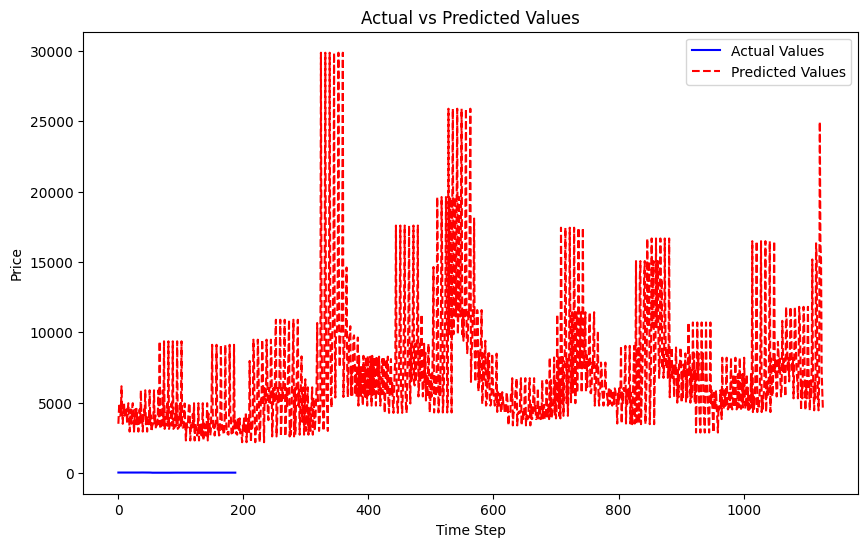

In [ ]:
y_pred_t = model.predict(X_test)

y_test_o = y_scaler.inverse_transform(y_test_s.reshape(-1, 1))
y_pred_t = y_scaler.inverse_transform(y_pred_t.reshape(-1, 1))

plt.figure(figsize=(10,6))
plt.plot(y_test_o, label='Actual Values', color='blue')
plt.plot(y_pred_t, label='Predicted Values', color='red', linestyle='dashed')
plt.title("Actual vs Predicted Values")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.show()